# Een eerste neuraal netwerk

In deze notebook wordt getoond hoe een neuraal netwerk opgebouwd kan worden met Pytorch.
Hierbij wordt er dieper ingegaan op de keuzes van hyperparameters.

In de eerste codecell importeren we de nodige functionaliteiten van pytorch. 
Daarna maken we ook een aantal variabelen aan die we gaan gebruiken voor het aanmaken van het netwerk.
De betekenis van deze parameters is:
* input_size: aantal features in de dataset
* hidden_size: aantal neuronen in de enkele hidden laag
* output_size: aantal neuronen in de outputlaag
* learning_rate: de learning rate van de optimizer
* epochs: aantal keer dat de volledige dataset gebruikt wordt voor training
* batch_size: hoeveel inputs er gegroepeerd worden voordat de gewichten geoptimaliseerd worden
* dropout_rate: het aantal connecties dat op een willekeurige manier zal wegvallen

Voor de input_size heb je meestal geen keuze. Deze wordt bepaald door de gegeven dataset. Elke feature van de input wordt namelijk gematchet op een neuron in de inputlayer.
Ook de output_size wordt bepaald door het probleem. Dit is de gewenste output dus:
* Bij een regressieprobleem is er 1 neuron per ter voorspellen waarde
* Bij classificatie is er 1 neuron per klasse
    * In het geval van 2 klassen kan je gebruik maken van 1 klasse

In [ ]:
!pip install scikit-learn matplotlib

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Configuratie
input_size = 20       # Aantal ingangsfeatures
hidden_size = 64      # Grootte van de verborgen lagen
output_size = 2       # Aantal klassen (voor classificatie)
learning_rate = 0.001 # Learning rate
epochs = 50           # Aantal epochs
batch_size = 32       # Batch grootte
dropout_rate = 0.5    # Dropout rate voor regularisatie

Na het bepalen van de configuratie kan de dataset gemaakt worden. Dit gebeurd met de make_classification functie van scikit-learn om met random data te werken.
In dit voorbeeld is er gekozen voor een classificatieprobleem met 2 klassen.

Deze dataset wordt daarna gesplits in features en labels, en gepslitst in trainings- en testdata.
In pytorch ziet dit eruit als volgt

In [2]:
# Dataset maken
X, y = make_classification(n_samples=1000, n_features=input_size, n_classes=output_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# DataLoader maken
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Methode 1: Klasieke techniek om NN op te stellen met pytorch
Hierna kan het neuraal netwerk aangemaakt worden.
Eerst gaan we werken met de klassieke en meest manuele manier.
Dit gaat misschien niet de meest beknopte manier zijn maar geeft je wel de meeste mogelijkheden om het model en trainingsproces aan te passen aan je noden.

De klassieke techniek met pytorch is om een klasse te maken die overerft van de Module-klasse.
In deze klasse moet je de volgende zaken aanpassen:

* In de constructor van deze klasse maak je de nodige lagen aan van het neuraal netwerk.
* In de forward functie van de klasse geef je dan hoe deze lagen aan elkaar gekoppeld worden.

In onderstaande voorbeeld worden vier eenvoudige lagen aangemaakt (1 voor de inputs, 2 voor de hiden layers en 1 voor de output layer). De activatiefunctie wordt toegevoegd in de forward functie. In het model hieronder is er gekozen om te werken met een Relu-functie na de input en hidden layer. De output layer bevat een standaard lienaire functie. Dit omdat pytorch beschikt over een speciale loss-functie om een sigmoid/softmax in de output layer overbodig te maken wat efficienter is.

In [3]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(NeuralNet, self).__init__()

        # maak de lagen aan
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc2(x) # hier zou je de sigmoid activatiefunctie nodig hebben
        return x

model = NeuralNet(input_size, hidden_size, output_size, dropout_rate)

In [4]:
print(model)

NeuralNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


Om dit model te trainen moet er eerst bepaald worden wat er moet geoptimaliseerd worden.
Dit is **de loss-functie** die moet geminimaliseerd worden.
Dit wordt ook bepaald door het op te lossen probleem, namelijk:

* Bij regressie wordt er typisch gekozen voor Mean-Squared-Error (noemt in pytorch MSELoss) of Mean-Squared-Error
* Bij classificatie wordt er gekozen voor
    * BCEWithLogitsLoss bij binaire classificatie (BCE staat voor Binary Cross Entropy )
        * Hierbij moet geen sigmoid activatiefunctie gebruikt worden want dit is reeds ingebouwd in de loss-functie
        * Indien er toch een sigmoid-functie gebruikt wordt in de output-layer: BCELoss
    * CrossEntropy in het geval van multi-class classification (meerdere opties maar slechts 1 klasse te kiezen)
    * BCEWithLogitsLoss bij multilabel classificatie
        *  Aangezien elk outputneuron een binaire classificatie is
     
Daarna wordt de training uitgevoerd door het aantal epoch keer de dataset te gebruiken om de gewichten te optimaliseren.
Hiervoor moet er per epoch het volgende uitgevoerd worden:
* Zet het model in een trainingsmodus
* Geef de data aan het model en doe per batch
    * Bereken de outputs
    * Bereken de error tussen de outputs en gewenste labels
    * Voer backwards propagation uit om gewichten up te daten
* Zet het model in een evaluatie modus
* Bereken de totale loss op de test-date
    *  Dit wordt gebruikt om de prestaties van het model op te volgen en kan gebruikt worden om het trainen eerder te stoppen indien er overfitting gedetecteerd wordt.

In [7]:
criterion = nn.CrossEntropyLoss() # loss-functie
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def train(model, train_loader, test_loader, epochs, criterion, optimizer):
    train_losses = []
    test_losses = []

    # voor elke epoch
    for epoch in range(epochs):
        # train het model
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            # train met deze batch
            optimizer.zero_grad() # reset de afgeleiden
            outputs = model(inputs) # forward-pass
            loss = criterion(outputs, labels) # bereken de loss
            loss.backward() # backwards propagation
            optimizer.step() # pas de gewichten aan

            running_loss += loss.item()

        train_losses.append(running_loss/len(train_loader))

        # evalueer het model
        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                # evalueer de batch
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

        test_losses.append(running_loss / len(test_loader))

    return train_losses, test_losses

train_losses, test_losses = train(model, train_loader, test_loader, epochs, criterion, optimizer)

In [8]:
train_losses

[3.7997787761688233,
 2.8934821033477784,
 1.7366990613937379,
 1.0492712879180908,
 0.7520906662940979,
 0.6332514059543609,
 0.5686486411094666,
 0.527967826128006,
 0.5186019384860993,
 0.4911669707298279,
 0.4694335168600082,
 0.4410300147533417,
 0.44463218212127686,
 0.41052185773849487,
 0.42098824739456175,
 0.42960349559783934,
 0.39688372194766997,
 0.4283498126268387,
 0.37652578234672546,
 0.4028299111127853,
 0.38772548973560333,
 0.3705026316642761,
 0.38287039518356325,
 0.37577588319778443,
 0.3740376365184784,
 0.3704086178541183,
 0.3666586434841156,
 0.35545287251472474,
 0.36141702890396116,
 0.37132336318492887,
 0.3544655829668045,
 0.3358285558223724,
 0.3436546802520752,
 0.341478191614151,
 0.3627368140220642,
 0.36307713747024534,
 0.32147195637226106,
 0.3216981565952301,
 0.3425800570845604,
 0.33025353252887724,
 0.34685068249702455,
 0.3340348905324936,
 0.3272085094451904,
 0.34515747845172884,
 0.3240409058332443,
 0.32792908787727354,
 0.322698574066162

De resultaten van het trainingsproces kunnen geplot worden met onderstaande code
De x-as stelt de prestaties van het model voor doorheen het trainingsproces.
Het resulteren model heeft dus de prestaties in de laatste epoch.
Deze figuur kan gebruikt worden om
* De stabiliteit van het model te valideren
    * Een onstabiel model (met veel variatie in de output zal niet goed generaliseren)
* Het aantal gekozen epochs/learning rate te valideren
    * Als de loss-functie nog snel daalt moet het aantal epochs of de learning rate verhoogd worden
* Underfitting detecteren
    * Als de error nog te hoog is voor je doelstelling is ofwel het model niet complex genoeg of de data niet goed genoeg 
* Overfitting detecteren
    * Als er een punt is waarop de test-loss (error op de testdata) terug toeneemt en de train-loss verder daalt. Dan treedt er vanaf die epoch overfitting op
    * Dit kan vermeden worden door meer regularisatie toe te voegen of de complexiteit van het model te verlagen
    * Het aantal epochs reduceren tot dit punt is niet goed want dan verlaag je de prestaties van je model.

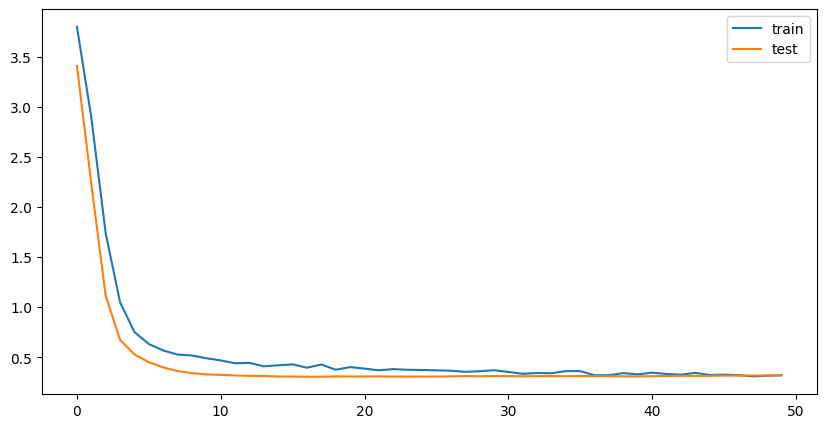

In [9]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend()
plt.show()

## Methode 2: Kortere maar minder flexibele schrijfwijze

Aangezien bovenstaande model een standaard structuur heeft kan het ook herschreven worden als een functioneel model.
In dit geval ziet de code eruit als volgt

In [ ]:
model = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(hidden_size, output_size)
)

Hierbij is de opbouw van het model vereenvoudigd maar **de traningslus moet nog steeds voluit geschreven worden**.

## Methode 3: Keras

Een derde manier om de code te schrijven is door middel van **Keras**. 
Deze manier van code schrijven is identiek aan hoe het eruitziet inden er gebruik gemaakt wordt van **Tensorflow**.
Met keras kan zowel de opbouw van het model als de trainingslus sterk vereenvoudigd worden.

Merk op dat hieronder **wel een softmax nodig is** omdat de standaard crossentropy functies van keras/tensorflow dit vereisen. 
Daarnaast is het ook interessant dat Keras een summary kan uitprinten van een model om een overzicht te krijgen van de architectuur en het aantal parameters dat in elke laag moet getrained worden.

In [10]:
from keras_core.models import Sequential
from keras_core.layers import Dense, Dropout
from keras_core.optimizers import Adam

model = Sequential()
model.add(Dense(hidden_size, activation='relu', input_shape=(input_size, )))
model.add(Dropout(dropout_rate))
model.add(Dense(hidden_size, activation='relu'))
model.add(Dropout(dropout_rate))
model.add(Dense(output_size, activation='softmax'))

# compileren van het model
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))

Using PyTorch backend.


/opt/conda/lib/python3.10/site-packages/keras_core/src/layers/core/dense.py:73: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5544 - loss: 0.8166 - val_accuracy: 0.8000 - val_loss: 0.5150
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6760 - loss: 0.6749 - val_accuracy: 0.8300 - val_loss: 0.4395
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7216 - loss: 0.5699 - val_accuracy: 0.8400 - val_loss: 0.3933
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7604 - loss: 0.5280 - val_accuracy: 0.8600 - val_loss: 0.3653
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7677 - loss: 0.4786 - val_accuracy: 0.8500 - val_loss: 0.3551
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7658 - loss: 0.5006 - val_accuracy: 0.8300 - val_loss: 0.3448
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7994 - loss: 0.4261 - val_accuracy: 0.8400 - val_loss: 0.3312
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7903 - loss: 0.4344 - val_accuracy: 0.8350 - val_loss:

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)                │      1,344 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dropout (Dropout)               │ (None, 64)                │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense_1 (Dense)                 │ (None, 64)                │      4,160 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dropout_1 (Dropout)             │ (None, 64)                │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ dense_2 (Dense)                 │ (None, 2)                 │        130 │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 16,904 (66.03 KB)

 Trainable params: 5,634 (22.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,270 (44.02 KB)

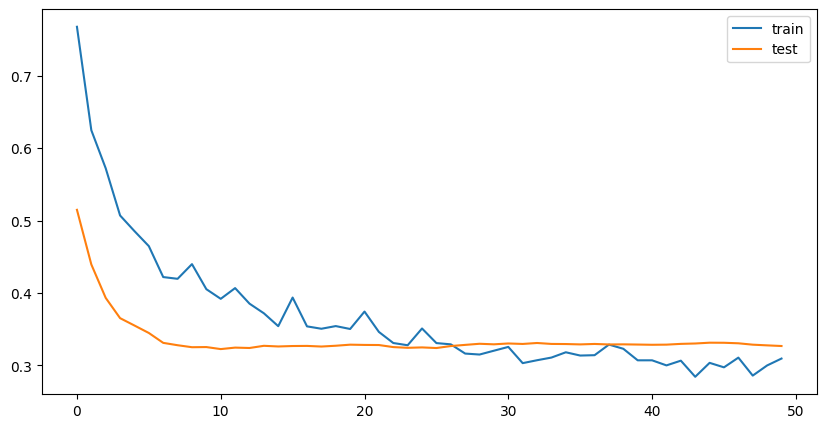

In [12]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

## Oefening 1: Binaire classificatie

Train een feed-forward neurale netwerk voor binaire classificatie met behulp van de make_classification functie van sklearn om een dataset te genereren.

Gebruik een eenvoudig netwerk met één verborgen laag van 64 neuronen en een sigmoid activatiefunctie.
Schrijf je code aan de hand van Keras

**Uitbreiding (ook voor alle andere oefeningen)** Oefen ook de andere code-schrijfwijzen

In [ ]:
# Dataset genereren
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Data splitsen in train en test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model opbouwen
model = Sequential([
    Dense(64, activation='relu', input_shape=(20,)),
    Dense(1, activation='sigmoid')
])

# Model compileren
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Model trainen
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Resultaten plotten
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluatie op de test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy of the model on the test set: {accuracy*100:.2f}%')


## Oefening 2: Multiklasse classificatie met Iris Dataset

Train een feed-forward neurale netwerk voor multiklasse classificatie met behulp van de load_iris functie van sklearn om de Iris dataset te laden.
Gebruik een netwerk met drie verborgen laag van 32 neuronen en een softmax activatiefunctie.

Schrijf je code aan de hand van nn.Sequential (tweede schrijfwijze)

In [ ]:
from sklearn.datasets import load_iris

# Dataset laden
iris = load_iris()
X, y = iris.data, iris.target

# Data splitsen in train en test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert naar PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Dataset en DataLoader maken
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model definieren met nn.Sequential
model = nn.Sequential(
    nn.Linear(4, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 3)  # 3 output klassen voor Iris dataset
)

# Loss functie en optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training van het model
epochs = 50
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Evaluatie op de test set
    model.eval()
    test_loss = 0.0
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
    test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(test_loss)
    
    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {epoch_loss:.4f}, '
          f'Test Loss: {test_loss:.4f}')

# Plot van train en test loss
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluatie van nauwkeurigheid op test set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Accuracy on the test set: {accuracy*100:.2f}%')


## Oefening 3: Regressie met Diabetes Dataset

Train een feed-forward neurale netwerk voor regressie met behulp van de load_diabetes functie van sklearn om de Diabetes dataset te laden.
Gebruik een netwerk met één verborgen laag van 64 neuronen en een gepaste activatiefunctie

Gebruik voor deze oefeningen de klassieke pytorch schrijfwijze

In [ ]:
from sklearn.datasets import load_diabetes

# Dataset laden
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Data splitsen in train en test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Converteren naar PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Unsqueezing om dimensie te matchen
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Dataset en DataLoader maken
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Definitie van het neurale netwerk met nn.Module
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(10, 64)   # 10 input features naar 64 hidden units
        self.fc2 = nn.Linear(64, 1)    # 64 hidden units naar 1 output (lineaire activatie)

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # ReLU activatie in de hidden layer
        x = self.fc2(x)               # Lineaire activatie in de output layer
        return x

# Model initialiseren
model = NeuralNet()

# Loss functie en optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training van het model
num_epochs = 200
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    epoch_train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * inputs.size(0)
    
    train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Evaluate on test set
    with torch.no_grad():
        model.eval()
        outputs = model(X_test_tensor)
        test_loss = criterion(outputs, y_test_tensor).item()
        test_losses.append(test_loss)
    
    model.train()

    #print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

# Plot van de trainings- en testverliezen
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluatie op de test set
with torch.no_grad():
    model.eval()
    outputs = model(X_test_tensor)
    test_loss = criterion(outputs, y_test_tensor).item()
    print(f'Mean Squared Error on the test set: {test_loss:.2f}')


## Oefening 4: Binaire classificatie met Moons Dataset

Train een feed-forward neurale netwerk voor binaire classificatie met behulp van de make_moons functie van sklearn om een maanvormige dataset te genereren.
Pas in deze oefening l2-regularisatie toe ipv dropout.

Gebruik de keras notatie met een pytorch backend (code hiervoor al gegeven hieronder)

In [ ]:
from sklearn.datasets import make_moons
from keras.regularizers import l2

# Dataset genereren
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Data splitsen in train en test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model opbouwen
model = Sequential([
    Dense(32, activation='relu', kernel_regularizer=l2(0.01), input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Model compileren
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Model trainen
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Resultaten plotten
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluatie op de test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy of the model on the test set: {accuracy*100:.2f}%')

## Oefening 5: Multilabel classificatie met Circles Dataset

Train een feed-forward neurale netwerk voor multilabel classificatie met behulp van de make_circles functie van sklearn om een dataset met cirkelvormige klassen te genereren.

Maak gebruik van nn.Module inheritance om dit model te schrijven en zorg voor regularisation door gebruik te maken van de L2-norm.

In [ ]:
from sklearn.datasets import make_circles

# Dataset genereren
X, y = make_circles(n_samples=1000, noise=0.1, random_state=42)

# Omzetten naar PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Data splitsen in train en test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definitie van het neurale netwerk met nn.Module
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 64)  # Input layer naar hidden layer
        self.fc2 = nn.Linear(64, 1)  # Hidden layer naar output layer
        self.relu = nn.ReLU()        # ReLU activatie voor hidden layer

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Model instantiëren
model = Net()

# Loss functie (Binary Cross Entropy) en optimizer (Adam)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)  # L1 regularisatie via weight_decay

# Training loop
epochs = 2000
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train.unsqueeze(1))
    train_losses.append(loss.item())
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        output_test = model(X_test)
        loss_test = criterion(output_test, y_test.unsqueeze(1))
        test_losses.append(loss_test.item())

    if epoch % 10 == 0:
        print(f'Epoch [{epoch}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {loss_test.item():.4f}')

# Plot train en test losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluatie op de test set
with torch.no_grad():
    model.eval()
    y_pred = model(X_test)
    y_pred_binary = torch.round(torch.sigmoid(y_pred))
    accuracy = (y_pred_binary.eq(y_test.view_as(y_pred_binary)).sum().item() / len(y_test)) * 100

print(f'Accuracy of the model on the test set: {accuracy:.2f}%')
